In [ ]:

!pip -q install -U opencv-python-headless

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [ ]:

IMAGE_URL = "https://raw.githubusercontent.com/vinay0410/Pedestrian_Detection/master/sample_images/pedestrian.jpg"
IMAGE_FILE = Path("pedestrian.jpg")

try:
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_FILE)
    print("Sample image downloaded.")
except Exception as e:
    print("Download failed:", e)

if not IMAGE_FILE.exists():
    try:
        from google.colab import files
        print("Upload a pedestrian image (.jpg/.jpeg/.png):")
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No image was uploaded.")
        IMAGE_FILE = Path(next(iter(uploaded)))
    except Exception as e:
        raise RuntimeError(
            "Please upload a pedestrian street image named pedestrian.jpg "
            "or rerun the notebook with internet access."
        ) from e

frame = cv2.imread(str(IMAGE_FILE))
if frame is None:
    raise ValueError("OpenCV could not read the selected image.")

print("Image loaded:", IMAGE_FILE)
print("Original size:", frame.shape[1], "x", frame.shape[0])

Sample image downloaded.
Image loaded: pedestrian.jpg
Original size: 950 x 361


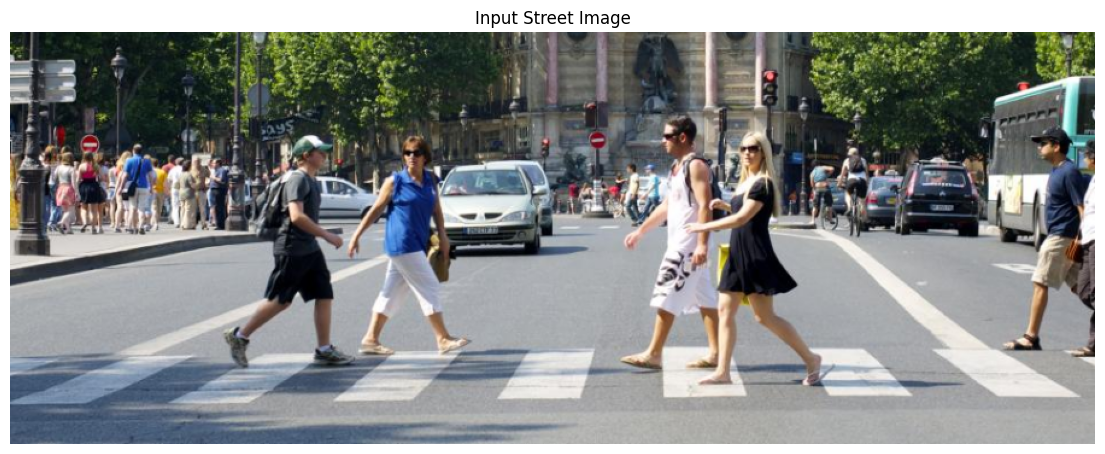

Processing size: 900 x 342


In [ ]:

MAX_WIDTH = 900

scale = min(1.0, MAX_WIDTH / frame.shape[1])

if scale < 1:
    frame = cv2.resize(
        frame,
        (int(frame.shape[1] * scale), int(frame.shape[0] * scale)),
        interpolation=cv2.INTER_AREA
    )

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,7))
plt.imshow(rgb)
plt.title("Input Street Image")
plt.axis("off")
plt.show()

print("Processing size:", frame.shape[1], "x", frame.shape[0])

In [ ]:

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

print("HOG + SVM pedestrian detector ready.")

HOG + SVM pedestrian detector ready.


In [ ]:

raw_boxes, raw_scores = hog.detectMultiScale(
    frame,
    winStride=(8, 8),
    padding=(16, 16),
    scale=1.04
)

raw_boxes = np.array(raw_boxes, dtype=np.int32)
raw_scores = np.asarray(raw_scores, dtype=float).reshape(-1)

print("Raw detections:", len(raw_boxes))

if len(raw_scores):
    print("Raw score range:",
          round(float(raw_scores.min()), 3),
          "to",
          round(float(raw_scores.max()), 3))

Raw detections: 3
Raw score range: 0.339 to 0.549


In [ ]:

SCORE_THRESHOLD = 0.15

if len(raw_boxes):
    confidence_mask = raw_scores > SCORE_THRESHOLD
    candidate_boxes = raw_boxes[confidence_mask]
    candidate_scores = raw_scores[confidence_mask]
else:
    candidate_boxes = np.empty((0,4), dtype=np.int32)
    candidate_scores = np.empty((0,), dtype=float)

print("Detections after confidence filtering:", len(candidate_boxes))

Detections after confidence filtering: 3


In [ ]:

def iou(box_a, box_b):
    ax1, ay1, aw, ah = box_a
    bx1, by1, bw, bh = box_b

    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = aw * ah
    area_b = bw * bh
    union = area_a + area_b - inter_area

    return inter_area / union if union else 0.0


def non_max_suppression(boxes, scores, overlap_threshold=0.45):
    if len(boxes) == 0:
        return np.empty((0,4), dtype=np.int32), np.empty((0,), dtype=float)

    order = np.argsort(scores)[::-1]
    keep = []

    while len(order):
        current = order[0]
        keep.append(current)

        remaining = []
        for idx in order[1:]:
            if iou(boxes[current], boxes[idx]) < overlap_threshold:
                remaining.append(idx)

        order = np.array(remaining, dtype=int)

    return boxes[keep], scores[keep]


final_boxes, final_scores = non_max_suppression(
    candidate_boxes,
    candidate_scores,
    overlap_threshold=0.45
)

print("Final detections after NMS:", len(final_boxes))

Final detections after NMS: 3


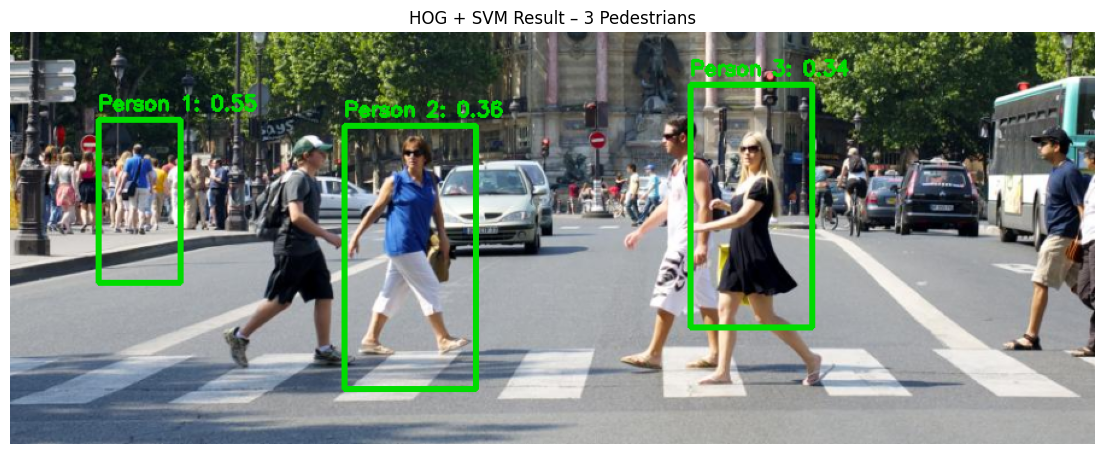

In [ ]:

result = frame.copy()

for idx, ((x, y, w, h), score) in enumerate(
    zip(final_boxes, final_scores), start=1
):
    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 220, 0),
        3
    )

    cv2.putText(
        result,
        f"Person {idx}: {score:.2f}",
        (x, max(18, y - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 220, 0),
        2
    )

plt.figure(figsize=(14,7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"HOG + SVM Result – {len(final_boxes)} Pedestrians")
plt.axis("off")
plt.show()

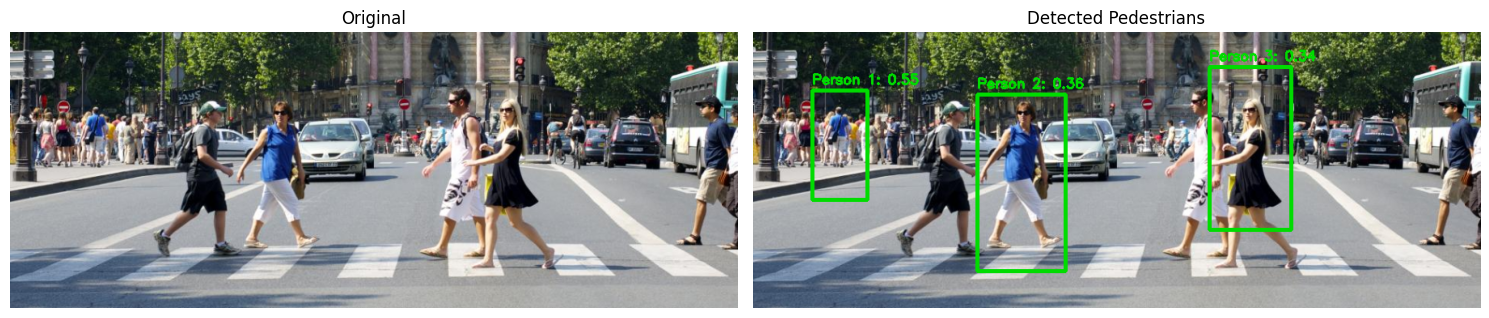

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title("Detected Pedestrians")
axes[1].axis("off")

plt.tight_layout()
plt.show()

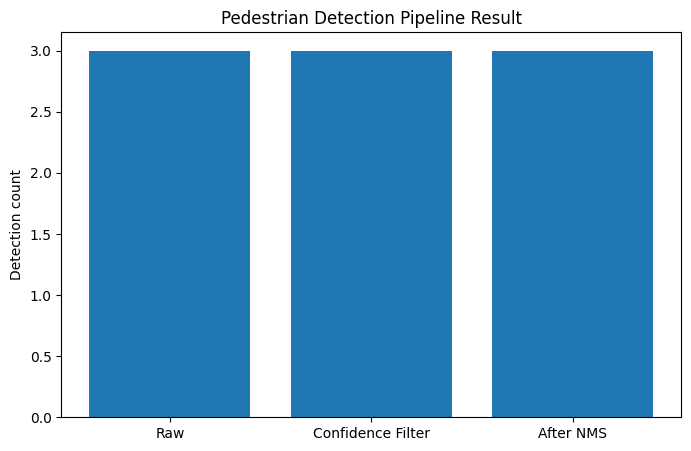

In [ ]:

stage_names = ["Raw", "Confidence Filter", "After NMS"]
stage_counts = [len(raw_boxes), len(candidate_boxes), len(final_boxes)]

plt.figure(figsize=(8,5))
plt.bar(stage_names, stage_counts)
plt.ylabel("Detection count")
plt.title("Pedestrian Detection Pipeline Result")
plt.show()

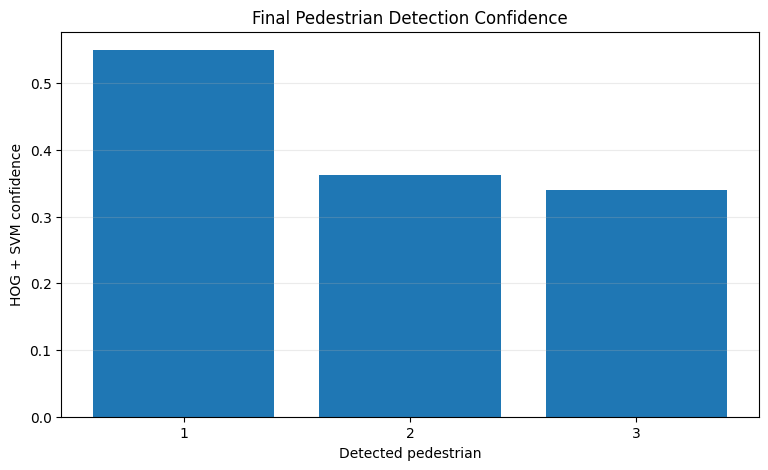

In [ ]:

if len(final_scores):
    plt.figure(figsize=(9,5))
    plt.bar(
        np.arange(1, len(final_scores)+1),
        final_scores
    )
    plt.xlabel("Detected pedestrian")
    plt.ylabel("HOG + SVM confidence")
    plt.title("Final Pedestrian Detection Confidence")
    plt.xticks(np.arange(1, len(final_scores)+1))
    plt.grid(axis="y", alpha=0.25)
    plt.show()
else:
    print("No final detections available for the confidence graph.")

In [ ]:

roi_polygon = np.array([
    [140, 120],
    [900, 120],
    [900, 342],
    [100, 342],
], dtype=np.int32)

print("ROI polygon points (x, y):")
print(roi_polygon)

ROI polygon points (x, y):
[[140 120]
 [900 120]
 [900 342]
 [100 342]]


In [ ]:

def foot_point(box):
    x, y, w, h = box
    return (int(x + w / 2), int(y + h))

def in_roi(point, polygon):

    return cv2.pointPolygonTest(polygon, (float(point[0]), float(point[1])), False) >= 0

road_mask = np.array([
    in_roi(foot_point(box), roi_polygon) for box in final_boxes
], dtype=bool)

road_boxes = final_boxes[road_mask] if len(final_boxes) else final_boxes
road_scores = final_scores[road_mask] if len(final_scores) else final_scores

excluded_boxes = final_boxes[~road_mask] if len(final_boxes) else final_boxes
excluded_scores = final_scores[~road_mask] if len(final_scores) else final_scores

print("Detections before ROI filtering:", len(final_boxes))
print("Detections on the road/crosswalk (kept):", len(road_boxes))
print("Detections off the road, e.g. on the sidewalk (excluded):", len(excluded_boxes))

Detections before ROI filtering: 3
Detections on the road/crosswalk (kept): 2
Detections off the road, e.g. on the sidewalk (excluded): 1


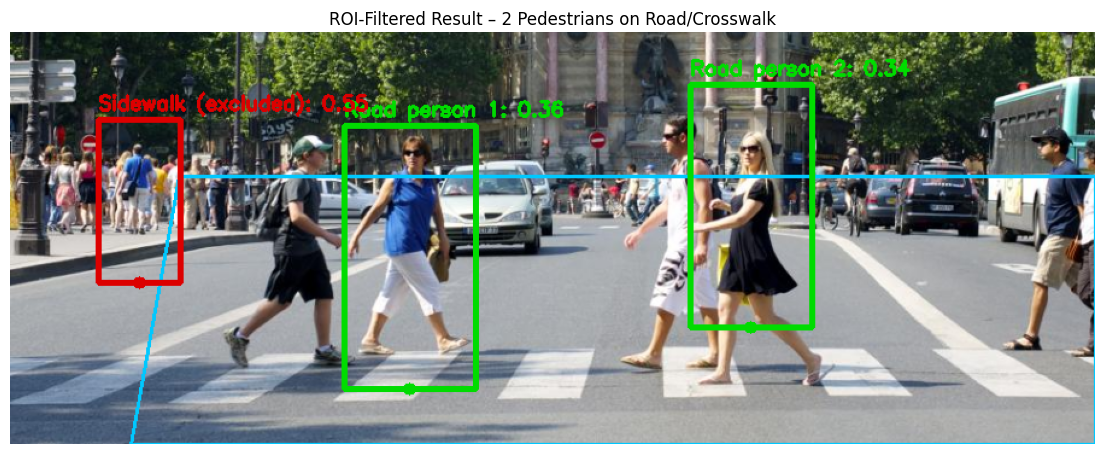

In [ ]:

roi_result = frame.copy()

cv2.polylines(roi_result, [roi_polygon], isClosed=True, color=(255, 200, 0), thickness=2)

for idx, ((x, y, w, h), score) in enumerate(zip(road_boxes, road_scores), start=1):
    cv2.rectangle(roi_result, (x, y), (x + w, y + h), (0, 220, 0), 3)
    cv2.putText(roi_result, f"Road person {idx}: {score:.2f}", (x, max(18, y - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 0), 2)
    fx, fy = foot_point((x, y, w, h))
    cv2.circle(roi_result, (fx, fy), 5, (0, 220, 0), -1)

for (x, y, w, h), score in zip(excluded_boxes, excluded_scores):
    cv2.rectangle(roi_result, (x, y), (x + w, y + h), (0, 0, 220), 3)
    cv2.putText(roi_result, f"Sidewalk (excluded): {score:.2f}", (x, max(18, y - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 220), 2)
    fx, fy = foot_point((x, y, w, h))
    cv2.circle(roi_result, (fx, fy), 5, (0, 0, 220), -1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(roi_result, cv2.COLOR_BGR2RGB))
plt.title(f"ROI-Filtered Result – {len(road_boxes)} Pedestrians on Road/Crosswalk")
plt.axis("off")
plt.show()

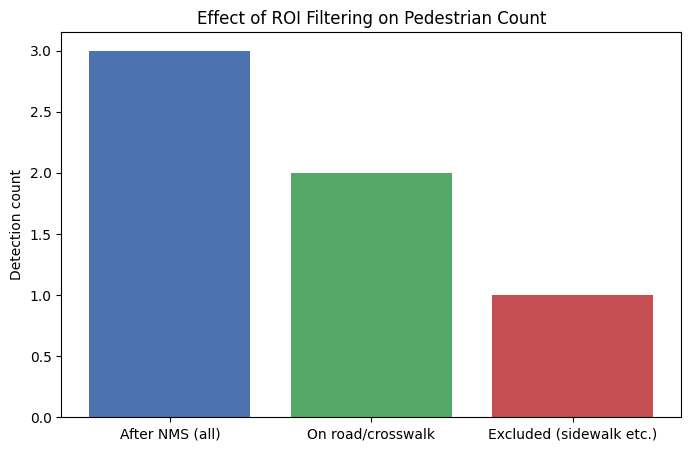

In [ ]:

roi_stage_names = ["After NMS (all)", "On road/crosswalk", "Excluded (sidewalk etc.)"]
roi_stage_counts = [len(final_boxes), len(road_boxes), len(excluded_boxes)]

plt.figure(figsize=(8, 5))
plt.bar(roi_stage_names, roi_stage_counts, color=["#4c72b0", "#55a868", "#c44e52"])
plt.ylabel("Detection count")
plt.title("Effect of ROI Filtering on Pedestrian Count")
plt.show()